In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from pathlib import Path

# Dataset Availability

## SONICS

In [2]:
# Load SONICS csv files
sonics_real = pd.read_csv('../sonics_dataset/real_songs.csv')
sonics_fake = pd.read_csv('../sonics_dataset/fake_songs.csv')

print("SONICS Dataset")
print(f"Full list of Real songs: {len(sonics_real)}")
print(f"Full list of Fake songs: {len(sonics_fake)}")
print(f"Full list of Train songs: {len(sonics_real)}")
print(f"Full list of Test songs: {len(sonics_fake)}")

# Display first few rows
print("\n--- Sample Real Songs ---")
display(sonics_real.head(3))
print("\n--- Sample Fake Songs ---")
display(sonics_fake.head(3))

# Compare with downloaded songs
downloaded_real = [f for f in os.listdir('../sonics_dataset/real_songs') if f.endswith('.mp3')]        # fewer due to YouTube rate limits
downloaded_fake = [f for f in os.listdir('../sonics_dataset/fake_songs/fake_songs') if f.endswith('.mp3')]

print(f"\nDownloaded Real songs: {len(downloaded_real)}")
print(f"Downloaded Fake songs: {len(downloaded_fake)}") 

SONICS Dataset
Full list of Real songs: 48090
Full list of Fake songs: 49074
Full list of Train songs: 48090
Full list of Test songs: 49074

--- Sample Real Songs ---


/tmp/ipykernel_3403368/1146729307.py:3: DtypeWarning: Columns (9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  sonics_fake = pd.read_csv('../sonics_dataset/fake_songs.csv')


,filename,title,artist,year,lyrics,duration,youtube_id,label,artist_overlap,target,skip_time,no_vocal,split
0,real_00000,Rap God,Eminem,2013,"[Intro]\n""Look, I was gonna go easy on you not...",240.084,EZ-yNVc9Htw,real,NaN,0,2.545344,False,train
1,real_00001,Shape of You,Ed Sheeran,2017,[Verse 1]\nThe club isn't the best place to fi...,240.084,JGwWNGJdvx8,real,NaN,0,15.876594,False,train
2,real_00002,HUMBLE.,Kendrick Lamar,2017,[Intro]\nNobody pray for me\nIt been that day ...,177.084,ov4WobPqoSA,real,NaN,0,4.047219,False,train



--- Sample Fake Songs ---


,id,lyrics,algorithm,style,filename,bit_rate,duration,source,lyrics_feature,topic,genre,mood,label,target,skip_time,no_vocal,split
0,54113,"[Intro]\n(Whoah)\nStaring at the stars, lost i...",chirp-v3.5,"male vocals, lounge, piano, saxophone, slow te...",fake_54113_suno_0,34956.0,239.076,suno,* subject_matter: “The song reflects on the jo...,star trek (TV),lounge,mournful,full fake,1,5.684094,False,train
1,53851,"[Intro]\n(Whisper) Athena, goddess of the nigh...",chirp-v3.5,"female vocals, salsa, piano, trumpet, percussi...",fake_53851_suno_0,37343.0,207.360,suno,* subject_matter: “The song tells the story of...,athena (myth),salsa,tense,full fake,1,6.865344,False,test
2,53851,"[Intro]\n(Whisper) Athena, goddess of the nigh...",chirp-v3.5,"female vocals, salsa, piano, trumpet, percussi...",fake_53851_suno_1,35928.0,230.184,suno,* subject_matter: “The song tells the story of...,athena (myth),salsa,tense,full fake,1,15.674094,False,test



Downloaded Real songs: 3037
Downloaded Fake songs: 49074


## FMC

In [3]:
# Explore FakeMusicCaps generators
fmc_dir = Path('../fake_music_caps_dataset')
generators = ['audioldm2', 'MusicGen_medium', 'musicldm', 'mustango', 'stable_audio_open']

print("FakeMusicCaps Dataset")

fmc_stats = {}
for gen in generators:
    gen_path = fmc_dir / gen
    if gen_path.exists():
        files = list(gen_path.glob('*.wav'))
        fmc_stats[gen] = len(files)
        print(f"{gen}: {len(files)} clips")

FakeMusicCaps Dataset
audioldm2: 5521 clips
MusicGen_medium: 5521 clips
musicldm: 5521 clips
mustango: 5521 clips
stable_audio_open: 5521 clips


## MIPPIA/SMP

In [4]:
# Load MIPPIA csv
mippia_smp = pd.read_csv('../smp_dataset/Final_dataset_pairs.csv')

print("MIPPIA SMP Dataset")
print(f"Total rows: {len(mippia_smp)}")
print(f"Unique pairs: {mippia_smp['pair_number'].nunique()}")

print("\n--- Sample Pairs ---")
display(mippia_smp.head(3))

# Compare with downloaded MIPPIA songs
mippia_pairs = os.listdir('../smp_dataset/final_dataset_clean')
print(f"\n Valid pairs after downloading: {len(mippia_pairs)}")


MIPPIA SMP Dataset
Total rows: 158
Unique pairs: 70

--- Sample Pairs ---


,ori_title,comp_title,ori_link,comp_link,relation,ori_times,comp_times,pair_number
0,Summer Dream,김민종 귀천도애(歸天道哀) (가사 첨부),https://www.youtube.com/watch?v=mwaVOpAUBDk,https://www.youtube.com/watch?v=UgSkgXFMxBU,plag,"[73, 81, 145, 153]","[86, 101, 204, 219]",1
1,Creedence Clearwater Revival - Run Through The...,The Old Man Down The Road,https://www.youtube.com/watch?v=_7PUPNxsRQ0,https://www.youtube.com/watch?v=gzah7VD_PM4,plag_doubt,"[20, 28]","[8, 15]",2
2,The Gap Band - Oops Upside Your Head,Mark Ronson - Uptown Funk (Official Video) ft....,https://www.youtube.com/watch?v=IeHDnF7MU90,https://www.youtube.com/watch?v=OPf0YbXqDm0,plag,"[3, 7, 11, 15, 20, 25, 29, 34, 38, 43, 66, 71,...","[176, 179, 183, 188, 234, 238, 242, 246, 250, ...",3



 Valid pairs after downloading: 60


### Useful Functions

In [5]:
def preprocess_audio(file_path, sr=22050, trim_silence=True):
    y, sr_original = librosa.load(file_path, sr=sr, mono=True)
    y = librosa.util.normalize(y)
    if trim_silence:
        y, _ = librosa.effects.trim(y, top_db=20)
    return y, sr_original

def extract_features(y, sr):
    features = {}    
    # MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    features['mfcc_mean'] = np.mean(mfccs, axis=1)
    features['mfcc_std'] = np.std(mfccs, axis=1)    
    # Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features['chroma_mean'] = np.mean(chroma, axis=1)
    features['chroma_std'] = np.std(chroma, axis=1)    
    # Spectral features
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features['spectral_centroid_mean'] = np.mean(spectral_centroid)
    features['spectral_centroid_std'] = np.std(spectral_centroid)    
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features['spectral_rolloff_mean'] = np.mean(spectral_rolloff)    
    features['spectral_rolloff_std'] = np.std(spectral_rolloff)    
    # Zero crossing rate
    zcr = librosa.feature.zero_crossing_rate(y)
    features['zcr_mean'] = np.mean(zcr)    
    features['zcr_std'] = np.std(zcr)    
    # Tempo
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features['tempo'] = tempo    
    return features

def compute_phase_continuity(y):
    D = librosa.stft(y)
    phase = np.angle(D)
    phase_diff = np.diff(np.unwrap(phase, axis=1), axis=1)
    continuity = 1.0 / (1.0 + np.std(phase_diff))    
    return continuity

def compute_hnr(y):
    y_harmonic, y_percussive = librosa.effects.hpss(y)
    harmonic_energy = np.sum(y_harmonic ** 2)
    percussive_energy = np.sum(y_percussive ** 2)
    if percussive_energy < 1e-10:
        return 100.0
    hnr = 10 * np.log10(harmonic_energy / percussive_energy)
    return hnr

def extract_features_extended(y, sr):
    features = extract_features(y, sr)
    features['phase_continuity'] = compute_phase_continuity(y)
    features['hnr'] = compute_hnr(y)
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    features['spectral_flux_mean'] = np.mean(onset_env)
    features['spectral_flux_std'] = np.std(onset_env)    
    return features


# Single files exploration

/home/st1054972/.conda/envs/ai_audio_proj/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Duration: 245.43s, Samples: 5411840


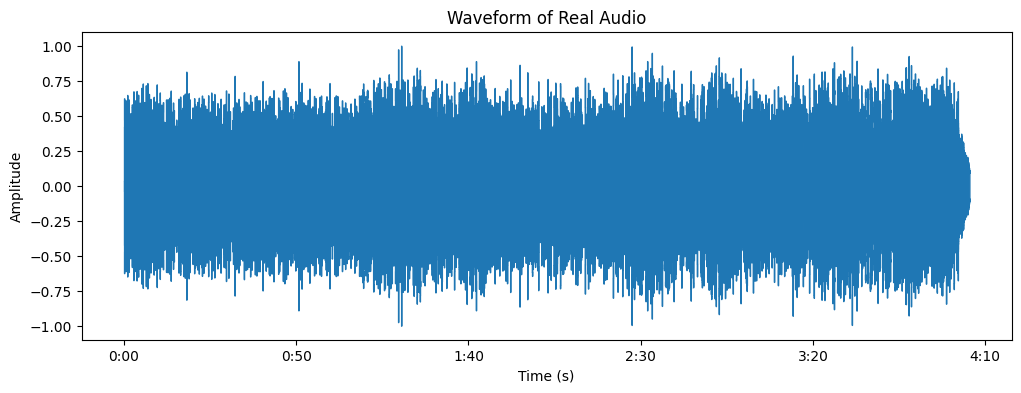

In [6]:
# real song example
y, sr = preprocess_audio('../smp_dataset/final_dataset_clean/1/Summer Dream.wav')
print(f"Duration: {len(y)/sr:.2f}s, Samples: {len(y)}")

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform of Real Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

Duration: 10.00s, Samples: 220500


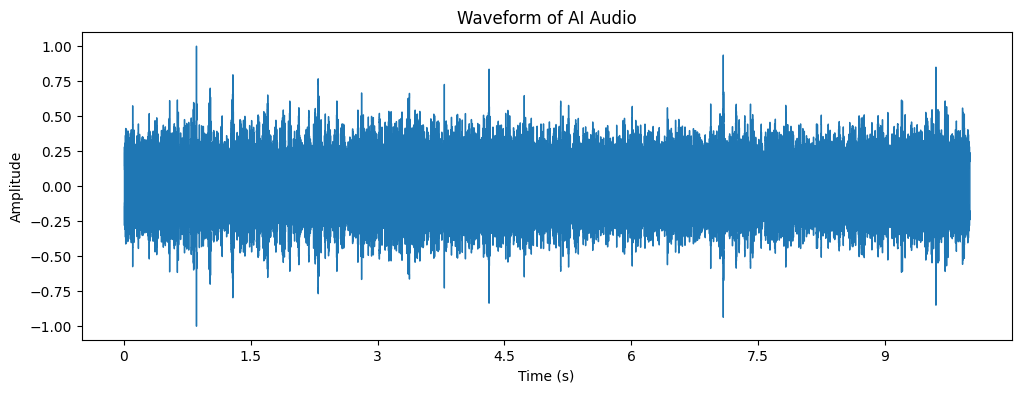

In [8]:
# ai audio example
y_fmc, sr_fmc = preprocess_audio('../fake_music_caps_dataset/audioldm2/_-kssA-FOzU.wav')
print(f"Duration: {len(y_fmc)/sr_fmc:.2f}s, Samples: {len(y_fmc)}")

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y_fmc, sr=sr_fmc)
plt.title("Waveform of AI Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

Duration: 218.52s, Samples: 4818432


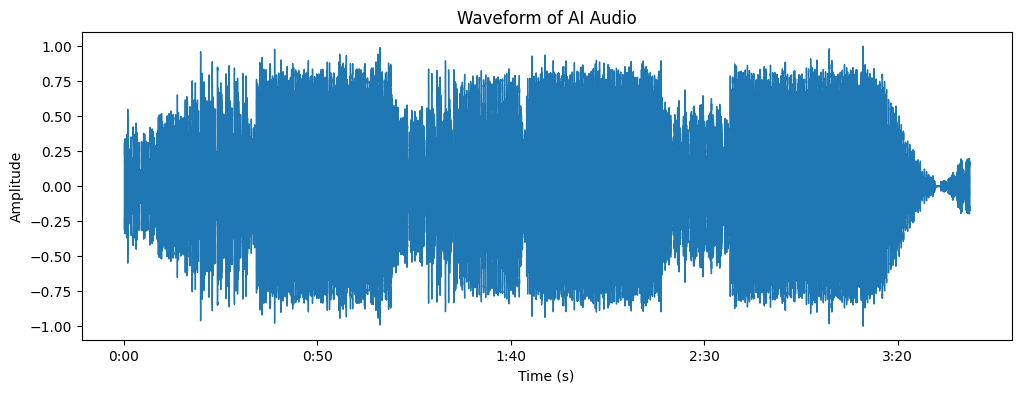

In [22]:
# ai song example
y_ai, sr_ai = preprocess_audio('../sonics_dataset/fake_songs/fake_songs/fake_00001_suno_0.mp3')
print(f"Duration: {len(y_ai)/sr_ai:.2f}s, Samples: {len(y_ai)}")

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y_ai, sr=sr_ai)
plt.title("Waveform of AI Audio")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

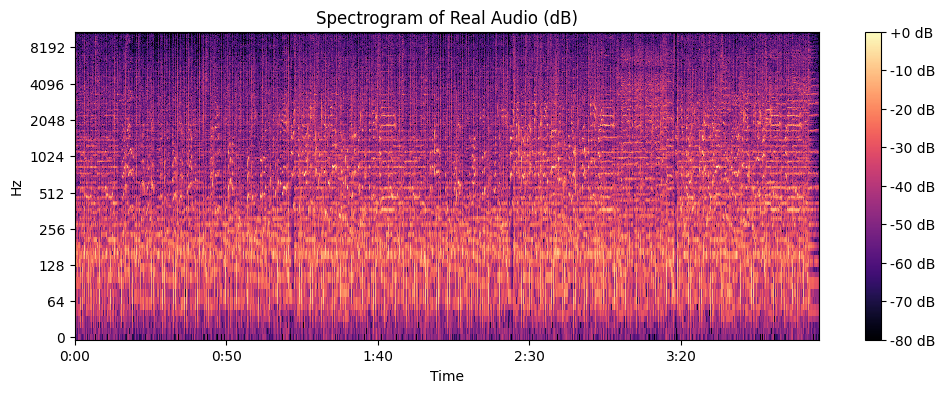

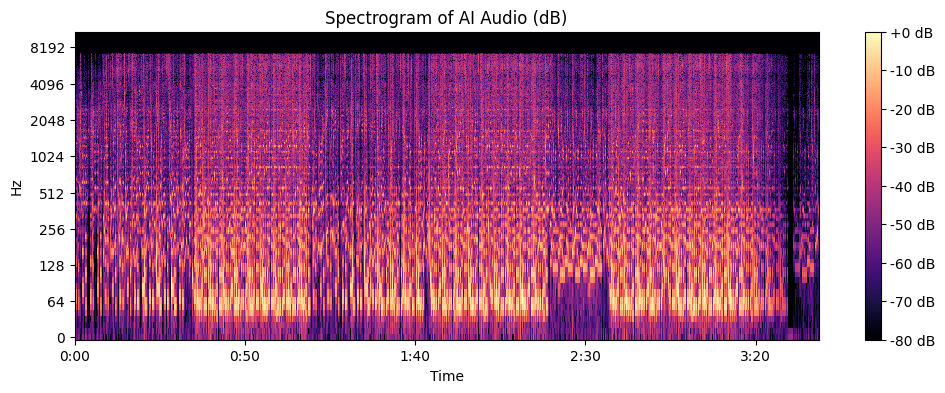

In [9]:
# Compute Short-Time Fourier Transform (STFT)
D = librosa.stft(y)
# Convert amplitude to decibels
S_db = librosa.amplitude_to_db(abs(D), ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram of Real Audio (dB)")
plt.show()

# Compute Short-Time Fourier Transform (STFT)
D_ai = librosa.stft(y_ai)
# Convert amplitude to decibels
S_db_ai = librosa.amplitude_to_db(abs(D_ai), ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db_ai, sr=sr_ai, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram of AI Audio (dB)")
plt.show()

In [10]:
features = extract_features_extended(y=y, sr=sr)
print("Extracted features for real audio:")
for key, value in features.items():
    print(f"{key}: {value}")

Extracted features for real audio:
mfcc_mean: [-81.347496   93.135124   -9.223198   22.783274    1.8724848   5.9075637
  -2.5857327   6.0175467  -1.3071165   0.2774774  -6.1159816  -3.0830114
  -4.355001 ]
mfcc_std: [47.52281   18.99111   13.768479  14.82274   10.9292     8.895715
  8.975195   7.023106   6.9051647  8.394988   7.5938735  7.413771
  6.291879 ]
chroma_mean: [0.320591   0.4781072  0.33151862 0.38210353 0.33159608 0.3612011
 0.45023364 0.3003266  0.39609227 0.33683273 0.4587392  0.34702682]
chroma_std: [0.24523093 0.3297684  0.23851022 0.30871892 0.29050317 0.27356017
 0.31930357 0.22009034 0.31541455 0.24091676 0.3389509  0.29194444]
spectral_centroid_mean: 2300.2498297955485
spectral_centroid_std: 464.30435254301347
spectral_rolloff_mean: 4780.105264310229
spectral_rolloff_std: 1044.1815707963297
zcr_mean: 0.11042629895468735
zcr_std: 0.03729741061234695
tempo: [135.99917763]
phase_continuity: 0.3546105623245239
hnr: 4.676541328430176
spectral_flux_mean: 1.238512158393859

In [11]:
features_ai = extract_features_extended(y=y_ai, sr=sr_ai)
print("Extracted features for AI-generated audio:")
for key, value in features_ai.items():
    print(f"{key}: {value}")

Extracted features for AI-generated audio:
mfcc_mean: [-119.64383    105.93397    -34.48391     63.949654   -20.8374
   43.91642    -17.334896    16.657227    -6.9043975   -5.0231404
    6.6408086  -10.922352    11.922476 ]
mfcc_std: [82.83318   29.909542  23.466825  24.361917  20.153667  18.340553
 15.0426445 12.9393425  9.930169  10.906193  10.796279   9.235595
  9.4538355]
chroma_mean: [0.36808702 0.40987095 0.28929898 0.35814065 0.36027336 0.32372984
 0.41926503 0.34178418 0.473771   0.37800702 0.34694338 0.4332716 ]
chroma_std: [0.27265468 0.34519675 0.23181301 0.28841597 0.32812175 0.26287854
 0.35118872 0.24565549 0.3450646  0.31985584 0.26756135 0.33260563]
spectral_centroid_mean: 2101.498327509679
spectral_centroid_std: 667.158831880397
spectral_rolloff_mean: 4659.686092533966
spectral_rolloff_std: 1152.17222993908
zcr_mean: 0.09043127498472694
zcr_std: 0.06697255358836404
tempo: [112.34714674]
phase_continuity: 0.35478290915489197
hnr: 6.124183654785156
spectral_flux_mean: 1.

# Batch Characteristics

In [12]:
def load_mippia_pairs(dataset_dir='../smp_dataset/final_dataset_clean', max_pairs=10):
    """Load audio file paths from MIPPIA pairs"""
    pairs = []
    dataset_path = Path(dataset_dir)
    
    for pair_folder in sorted(dataset_path.iterdir())[:max_pairs]:
        if pair_folder.is_dir():
            audio_files = list(pair_folder.glob('*.wav'))
            if len(audio_files) == 2:
                pairs.append({
                    'pair_id': pair_folder.name,
                    'song1': str(audio_files[0]),
                    'song2': str(audio_files[1])
                })
    
    return pairs

def load_fake_music_caps(dataset_dir='../fake_music_caps_dataset', max_per_generator=10):
    """Load audio files from FakeMusicCaps generators"""
    generators = ['audioldm2', 'MusicGen_medium', 'musicldm', 'mustango', 'stable_audio_open']
    audio_files = {}
    
    for gen in generators:
        gen_path = Path(dataset_dir) / gen
        if gen_path.exists():
            files = list(gen_path.glob('*.wav'))[:max_per_generator]
            audio_files[gen] = [str(f) for f in files]
    
    return audio_files

def load_sonics_files(fake_dir='../sonics_dataset/fake_songs/fake_songs', 
                      real_dir='../sonics_dataset/real_songs',
                      max_files=20):
    """Load SONICS real and fake audio files"""
    fake_path = Path(fake_dir)
    real_path = Path(real_dir)
    
    fake_files = list(fake_path.glob('*.mp3'))[:max_files] if fake_path.exists() else []
    real_files = list(real_path.glob('*.mp3'))[:max_files] if real_path.exists() else []
    
    return {
        'fake': [str(f) for f in fake_files],
        'real': [str(f) for f in real_files]
    }

In [13]:
# MIPPIA
pairs = load_mippia_pairs(max_pairs=5)
print(f"Loaded {len(pairs)} pairs")
print(f"First pair: {pairs[0]['pair_id']}")
print(f"Song 1: {pairs[0]['song1']}")
print(f"Song 2: {pairs[0]['song2']}")

# FMC
fmc_files = load_fake_music_caps(max_per_generator=20)
print(f"\nGenerators: {list(fmc_files.keys())}")
for gen, files in fmc_files.items():
    print(f"{gen}: {len(files)} files")
# Get first file from audioldm2
if 'audioldm2' in fmc_files and fmc_files['audioldm2']:
    first_file = fmc_files['audioldm2'][0]
    print(f"Sample audioldm2 file: {first_file}")

# SONICS
sonics = load_sonics_files(max_files=50)
print(f"\nReal songs: {len(sonics['real'])}")
print(f"Fake songs: {len(sonics['fake'])}")
if sonics['fake']:
    print(f"Sample AI song: {Path(sonics['fake'][0]).name}")

Loaded 5 pairs
First pair: 1
Song 1: ../smp_dataset/final_dataset_clean/1/김민종   귀천도애_歸天道哀_ _가사 첨부_.wav
Song 2: ../smp_dataset/final_dataset_clean/1/Summer Dream.wav

Generators: ['audioldm2', 'MusicGen_medium', 'musicldm', 'mustango', 'stable_audio_open']
audioldm2: 20 files
MusicGen_medium: 20 files
musicldm: 20 files
mustango: 20 files
stable_audio_open: 20 files
Sample audioldm2 file: ../fake_music_caps_dataset/audioldm2/UsdoUjuczY4.wav

Real songs: 50
Fake songs: 50
Sample AI song: fake_16591_udio_0.mp3


In [14]:
def batch_extract_features(file_paths, label, sr=22050, use_extended=True):
    """Extract features from multiple files"""
    results = []
    
    feature_fn = extract_features_extended if use_extended else extract_features
    
    for file_path in file_paths:
        # Preprocess
        y, sr = preprocess_audio(file_path, sr=sr)
        
        # Extract features
        features = feature_fn(y, sr)
        features['file_path'] = file_path
        features['label'] = label
        features['duration'] = len(y) / sr
        
        results.append(features)
    
    return pd.DataFrame(results)

In [44]:
# Get MIPPIA files
pairs = load_mippia_pairs(max_pairs=10)
mippia_files = []
for pair in pairs:
    mippia_files.extend([pair['song1'], pair['song2']])

df_mippia = batch_extract_features(mippia_files, label='real', use_extended=True)
print(df_mippia.head())

                                           mfcc_mean  \
0  [-101.091484, 102.63343, 0.5452056, 22.979593,...   
1  [-81.347496, 93.135124, -9.223198, 22.783274, ...   
2  [-104.67213, 79.51823, -0.14572525, 23.858143,...   
3  [-65.65864, 89.57463, -7.5168843, 24.557465, -...   
4  [-126.35118, 89.63147, 23.825169, 14.9698105, ...   

                                            mfcc_std  \
0  [93.91504, 28.676094, 21.100727, 16.625689, 11...   
1  [47.52281, 18.99111, 13.768479, 14.82274, 10.9...   
2  [106.813156, 34.60606, 23.131618, 14.969732, 1...   
3  [55.21657, 27.81999, 17.470377, 16.485899, 11....   
4  [83.62485, 27.905142, 22.056635, 15.915512, 16...   

                                         chroma_mean  \
0  [0.28017843, 0.32626402, 0.21337092, 0.3139406...   
1  [0.320591, 0.4781072, 0.33151862, 0.38210353, ...   
2  [0.2894981, 0.369659, 0.4188648, 0.3751664, 0....   
3  [0.40599653, 0.4247208, 0.3311739, 0.32875985,...   
4  [0.25288245, 0.32607338, 0.23520666, 0.2865